In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, r2_score, root_mean_squared_error
from utils.helpers import load_dataset, add_load_features
from utils.model_config import NOWCAST_CONFIG

# Nowcast

This notebook was used to establish the base workflow of training an XGBoost nowcasting model.

# Load data

In [3]:
project_root = Path.cwd().parent.parent.parent
interval = 60

path = project_root / f"data/time_series_{interval}.csv"
df = load_dataset(path)

# Extract each country column into separate DataFrame
### and remove outliers

In [4]:
countries = set([c[:2].upper() for c in df.columns if "timestamp" not in c])
countries_data = {}

for c in countries:
    target = f"{c}_load_actual_entsoe_transparency"
    df_c = pd.DataFrame(df[target])

    Q3 = df_c[target].quantile(0.75)
    upper_bound = 2.5*Q3
    mask = (df_c[target] > upper_bound)

    if mask.sum() > 0:
        print(f"Removing {mask.sum()} outliers from {c} dataset.")
        df_c = df_c[~mask]

    df_c = add_load_features(df_c, target, interval, type="nowcast")
    mask_valid_target = df_c[target].notna() # Extract rows where target is valid (not null)
    df_c = df_c[mask_valid_target].copy() # Take into DataFrame only rows with valid target
    countries_data[c] = df_c

for idx, c in enumerate(countries_data):
    if not idx % 5:
        print(f"{c} shape: {countries_data[c].shape}")

Removing 10 outliers from SK dataset.
Removing 1 outliers from FR dataset.
Removing 1 outliers from CH dataset.
CY shape: (32931, 27)
GB shape: (50394, 27)
IT shape: (50398, 27)
EE shape: (50318, 27)
LV shape: (50363, 27)
LT shape: (50207, 27)
RO shape: (50276, 27)


# Create training data for each country

In [5]:
model_data = {}

for c in countries:
    df_c = countries_data[c]
    target = f"{c}_load_actual_entsoe_transparency"   
    X = df_c.drop(target, axis=1).to_numpy()
    y = df_c[target].to_numpy()
    model_data[c] = {"X": X, "y": y}

for idx, key in enumerate(model_data):
    if not idx % 5:
        print(f"{key} || X: {model_data[key]['X'].shape}, y: {model_data[key]['y'].shape}")

CY || X: (32931, 26), y: (32931,)
GB || X: (50394, 26), y: (50394,)
IT || X: (50398, 26), y: (50398,)
EE || X: (50318, 26), y: (50318,)
LV || X: (50363, 26), y: (50363,)
LT || X: (50207, 26), y: (50207,)
RO || X: (50276, 26), y: (50276,)


# Model training

In [6]:
models = {}
gap_multiplier = 4 if interval == 15 else 1
gap = 168 * gap_multiplier
val_size = 168 * gap_multiplier

for idx, country in enumerate(model_data):

    X, y = model_data[country]["X"], model_data[country]["y"]

    X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    X_val, y_val = X_train_full[-val_size:], y_train_full[-val_size:]
    X_train, y_train = X_train_full[:-val_size - gap], y_train_full[:-val_size - gap]

    params = NOWCAST_CONFIG[interval]
    model_c = xgb.XGBRegressor(**params)

    # makni eval set i early stopping rounds
    model_c.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

    if not idx % 5:
        n_estimators_used = model_c.best_iteration + 1
        final_rmse = model_c.best_score
        print(f"----- Training {country} model -----")
        print(f"Number of estimators: {n_estimators_used}")
        print(f"Final RMSE: {final_rmse:.4f}")

    models[country] = model_c

----- Training CY model -----
Number of estimators: 671
Final RMSE: 5.9168
----- Training GB model -----
Number of estimators: 128
Final RMSE: 619.9503
----- Training IT model -----
Number of estimators: 2139
Final RMSE: 348.1813
----- Training EE model -----
Number of estimators: 414
Final RMSE: 11.4541
----- Training LV model -----
Number of estimators: 1958
Final RMSE: 8.4227
----- Training LT model -----
Number of estimators: 1070
Final RMSE: 12.2422
----- Training RO model -----
Number of estimators: 1703
Final RMSE: 51.3449


# Evaluate models on test data

In [7]:
for idx, country in enumerate(model_data):

    if not idx % 5:
        X, y = model_data[country]["X"], model_data[country]["y"]
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
        model_c = models[country]

        y_pred = model_c.predict(X_test)
        rmse = root_mean_squared_error(y_test, y_pred)
        mape = mean_absolute_percentage_error(y_test, y_pred)*100
        r2 = r2_score(y_test, y_pred)

        print(f'{country} model || Test RMSE: {rmse}, MAPE: {mape:.3f}%, R2: {r2:.4f}')

CY model || Test RMSE: 15.552070246110679, MAPE: 2.581%, R2: 0.9875
GB model || Test RMSE: 1498.5390248465026, MAPE: 3.326%, R2: 0.9628
IT model || Test RMSE: 414.9010106396643, MAPE: 0.985%, R2: 0.9969
EE model || Test RMSE: 12.23080159196539, MAPE: 1.034%, R2: 0.9956
LV model || Test RMSE: 8.724715232602147, MAPE: 0.786%, R2: 0.9970
LT model || Test RMSE: 15.512374833317988, MAPE: 0.857%, R2: 0.9960
RO model || Test RMSE: 62.3348032528017, MAPE: 0.693%, R2: 0.9963


# Plot random test set time series

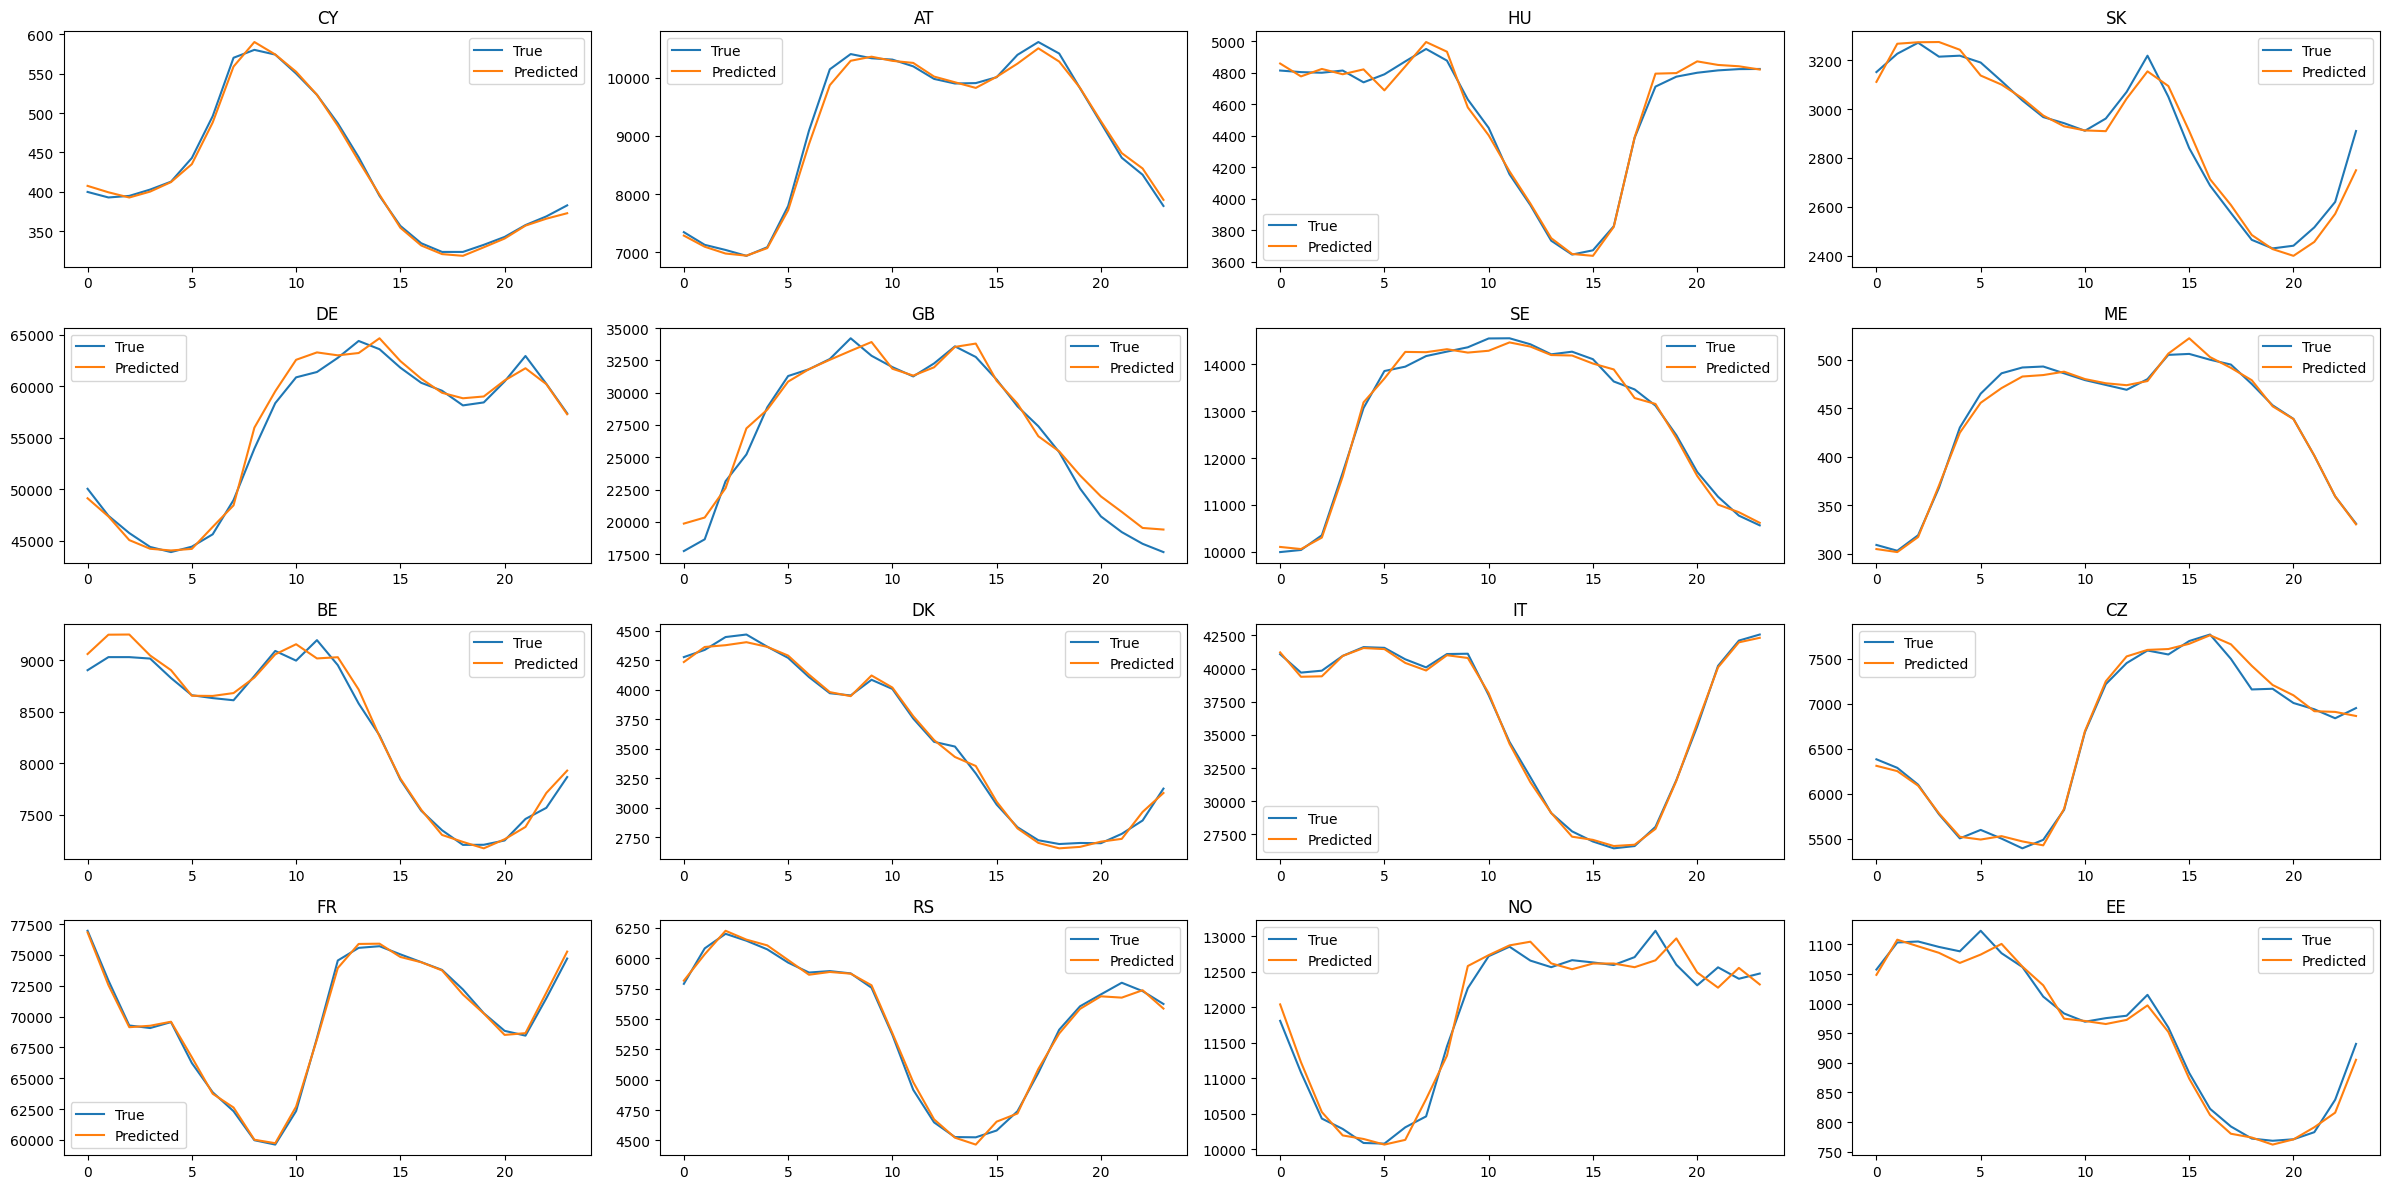

In [8]:
fig, ax = plt.subplots(nrows=4, ncols=4, figsize=(24, 12))
ax = ax.flatten()

for i, country in enumerate(list(countries)[:16]):

    X, y = model_data[country]["X"], model_data[country]["y"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
    model_c = models[country]

    window = 24
    idx = np.random.randint(0, len(X_test) - window)

    y_pred = model_c.predict(X_test[idx:idx+window])

    ax[i].plot(range(len(X_test[idx:idx+window])), y_test[idx:idx+window], label="True")
    ax[i].plot(range(len(X_test[idx:idx+window])), y_pred, label="Predicted")
    ax[i].set_title(country)
    ax[i].legend()

plt.tight_layout()
plt.show()

# Nowcast 60min results

| Country | n_estimators | Train RMSE | Test RMSE | Test MAPE | Test R² |
|---------|-------------:|-----------:|----------:|-----:|---:|
| AT | 1568 | 55.498 | 78.236 | 0.875% | 0.9968 |
| BE | 1089 | 94.520 | 130.253 | 1.088% | 0.9904 |
| BG | 831 | 36.178 | 50.391 | 0.911% | 0.9961 |
| CH | 397 | 161.689 | 203.930 | 2.111% | 0.9525 |
| CY | 671 | 5.917 | 15.552 | 2.581% | 0.9875 |
| CZ | 2141 | 43.655 | 68.721 | 0.736% | 0.9973 |
| DE | 1914 | 541.472 | 603.373 | 0.874% | 0.9962 |
| DK | 718 | 35.943 | 73.801 | 1.040% | 0.9889 |
| EE | 414 | 11.454 | 12.231 | 1.034% | 0.9956 |
| ES | 3000 | 142.428 | 338.361 | 0.866% | 0.9947 |
| FI | 638 | 51.934 | 79.816 | 0.698% | 0.9962 |
| FR | 2998 | 282.578 | 481.939 | 0.693% | 0.9980 |
| GB | 128 | 619.950 | 1498.539 | 3.326% | 0.9628 |
| GR | 936 | 57.081 | 79.822 | 1.097% | 0.9952 |
| HR | 1160 | 21.971 | 22.217 | 0.845% | 0.9965 |
| HU | 2620 | 36.415 | 50.769 | 0.717% | 0.9953 |
| IE | 2913 | 29.070 | 41.858 | 0.876% | 0.9954 |
| IT | 2139 | 348.181 | 414.901 | 0.985% | 0.9969 |
| LT | 1070 | 12.242 | 15.512 | 0.857% | 0.9960 |
| LU | 656 | 12.687 | 23.068 | 4.381% | 0.9443 |
| LV | 1958 | 8.423 | 8.725 | 0.786% | 0.9970 |
| ME | 1181 | 7.619 | 8.204 | 1.437% | 0.9876 |
| NL | 1492 | 95.345 | 179.432 | 1.021% | 0.9914 |
| NO | 1050 | 97.881 | 196.261 | 0.768% | 0.9954 |
| PL | 2282 | 95.613 | 147.540 | 0.593% | 0.9978 |
| PT | 1743 | 34.095 | 62.077 | 0.811% | 0.9963 |
| RO | 1703 | 51.345 | 62.335 | 0.693% | 0.9963 |
| RS | 1592 | 53.105 | 58.369 | 0.961% | 0.9956 |
| SE | 963 | 126.333 | 263.011 | 1.134% | 0.9924 |
| SI | 476 | 42.224 | 31.933 | 1.641% | 0.9864 |
| SK | 984 | 27.388 | 66.009 | 1.118% | 0.9824 |
| UA | 816 | 165.469 | 239.582 | 1.245% | 0.9813 |

# Nowcast 15min results

| Country | n_estimators | Train RMSE | Test RMSE | Test MAPE | Test R² |
|---------|-------------:|-----------:|----------:|-----:|---:|
| AT | 1120 | 41.194 | 48.783 | 0.551% | 0.9988 |
| BE | 1145 | 85.124 | 109.586 | 0.909% | 0.9932 |
| DE | 1901 | 312.174 | 397.149 | 0.568% | 0.9984 |
| HU | 2440 | 23.930 | 37.958 | 0.473% | 0.9974 |
| LU | 625 | 7.424 | 16.135 | 2.892% | 0.9732 |
| NL | 1211 | 68.673 | 95.420 | 0.522% | 0.9976 |